#📌 Extracción

## Cap 1-1 Extracción de datos

In [1]:
# Importamos librerías para manipulación de datos
import requests
import pandas as pd

In [2]:
# Definimos la fuente de datos (archivo JSON desde GitHub)
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

# Alternativamente, podríamos usar una ruta local(drive) si el archivo estuviera descargado
# url = '/content/TelecomX_Data.json'

In [3]:
# Realizamos la solicitud a la API y obtenemos los datos en formato JSON
response = requests.get(url)
data = response.json()

# Convertimos los datos JSON en un DataFrame de Pandas
df = pd.DataFrame(data)

## Cap 1-2 Conoce el conjunto de datos

In [4]:
# Observamos una muestra aleatoria de registros
df.sample(5)

,customerID,Churn,customer,phone,internet,account
2064,2905-KFQUV,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
5068,6922-NCEDI,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'One year', 'PaperlessBilling': '..."
2900,4018-KJYUY,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4868,6655-LHBYW,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'One year', 'PaperlessBilling': '..."
2840,3941-XTSKM,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'No', 'MultipleLines': 'No ph...","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."


In [5]:
# Revisamos columnas, tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#🔧 Transformación

## Cap 2-1 Comprobación de incoherencias en los datos

In [6]:
# Normalizamos el JSON para expandir las estructuras anidadas en columnas
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
# Revisamos estructura, tipos y nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [8]:
# Contamos valores nulos por columna
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [9]:
# Verificamos duplicados
df.duplicated().sum()

np.int64(0)

In [10]:
# Revisamos valores únicos de la variable objetivo
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

## Cap 2-2 Manejo de inconsistencias

In [11]:
# Eliminamos filas con Churn vacío
df = df[df['Churn'] != '']

In [12]:
columnas = {
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tiene +60',
    'customer.Partner': 'posee_pareja',
    'customer.Dependents': 'posee_dependientes',
    'customer.tenure': 'tiempo_contrato',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_digital',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns=columnas)
df

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [13]:
# Confirmamos que Churn ya no tiene valores vacíos
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

## Cap 2-3 Columna de cuentas diarias (Opcional)

In [14]:
# Convertimos el cargo mensual a numérico por si hay strings
df['valor_mensal'] = pd.to_numeric(df['valor_mensal'], errors='coerce')

In [15]:
# Convertimos cargo total a numérico ya que estaba como string
df['total_cobrado'] = pd.to_numeric(df['total_cobrado'], errors='coerce')

In [16]:
# Creamos columna con el valor diario aproximado (mensual / 30)
df['cuentas_diarias'] = df['valor_mensal'] / 30

df[['valor_mensal', 'cuentas_diarias']].head()

,valor_mensal,cuentas_diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


## Cap 2-4 Estandarización y transformación de datos (Opcional)

In [17]:
# Mapeamos Yes/No a 1/0 en columnas binarias relevantes
binary_cols = [
    'Churn', 'posee_pareja', 'posee_dependientes',
    'servicio_telefono', 'factura_digital'
]
df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'Yes': 1, 'No': 0}))

df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [18]:
# Traducimos los valores categóricos al español
df['genero'] = df['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})

df['multiples_lineas'] = df['multiples_lineas'].replace({
    'Yes': 'Sí', 'No': 'No', 'No phone service': 'Sin servicio de teléfono'
})

df['tipo_internet'] = df['tipo_internet'].replace({
    'Fiber optic': 'Fibra óptica', 'DSL': 'DSL', 'No': 'Sin internet'
})

df['tipo_contrato'] = df['tipo_contrato'].replace({
    'Month-to-month': 'Mensual', 'One year': 'Anual', 'Two year': 'Bienal'
})

df['metodo_pago'] = df['metodo_pago'].replace({
    'Electronic check':          'Cheque electrónico',
    'Mailed check':              'Cheque por correo',
    'Bank transfer (automatic)': 'Transferencia bancaria',
    'Credit card (automatic)':   'Tarjeta de crédito'
})

# Columnas con Yes/No restantes
yes_no_cols = ['seguridad_online', 'backup_online',
               'proteccion_dispositivo', 'soporte_tecnico',
               'streaming_tv', 'streaming_peliculas']

for col in yes_no_cols:
    df[col] = df[col].replace({
        'Yes': 'Sí', 'No': 'No', 'No internet service': 'Sin internet'
    })

df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,cuentas_diarias
0,0002-ORFBO,0,Femenino,0,1,1,9,1,No,DSL,...,No,Sí,Sí,No,Anual,1,Cheque por correo,65.6,593.30,2.186667
1,0003-MKNFE,0,Masculino,0,0,0,9,1,Sí,DSL,...,No,No,No,Sí,Mensual,0,Cheque por correo,59.9,542.40,1.996667
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,No,Fibra óptica,...,Sí,No,No,No,Mensual,1,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,1,Masculino,1,1,0,13,1,No,Fibra óptica,...,Sí,No,Sí,Sí,Mensual,1,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,No,Fibra óptica,...,No,Sí,Sí,No,Mensual,1,Cheque por correo,83.9,267.40,2.796667


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7043 non-null   object 
 1   Churn                   7043 non-null   int64  
 2   genero                  7043 non-null   object 
 3   tiene +60               7043 non-null   int64  
 4   posee_pareja            7043 non-null   int64  
 5   posee_dependientes      7043 non-null   int64  
 6   tiempo_contrato         7043 non-null   int64  
 7   servicio_telefono       7043 non-null   int64  
 8   multiples_lineas        7043 non-null   object 
 9   tipo_internet           7043 non-null   object 
 10  seguridad_online        7043 non-null   object 
 11  backup_online           7043 non-null   object 
 12  proteccion_dispositivo  7043 non-null   object 
 13  soporte_tecnico         7043 non-null   object 
 14  streaming_tv            7043 non-null   objec

#📊 Carga y análisis

## Cap 3-1 Análisis Descriptivo

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [21]:
# Resumen estadístico de las variables numéricas
df.describe()

,Churn,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,factura_digital,valor_mensal,total_cobrado,cuentas_diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


## Cap 3-2 Distribución de Evasión

In [22]:
# Conteo y porcentaje
conteo     = df['Churn'].value_counts()
porcentaje = df['Churn'].value_counts(normalize=True) * 100
print(conteo)
print(porcentaje.round(2))

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


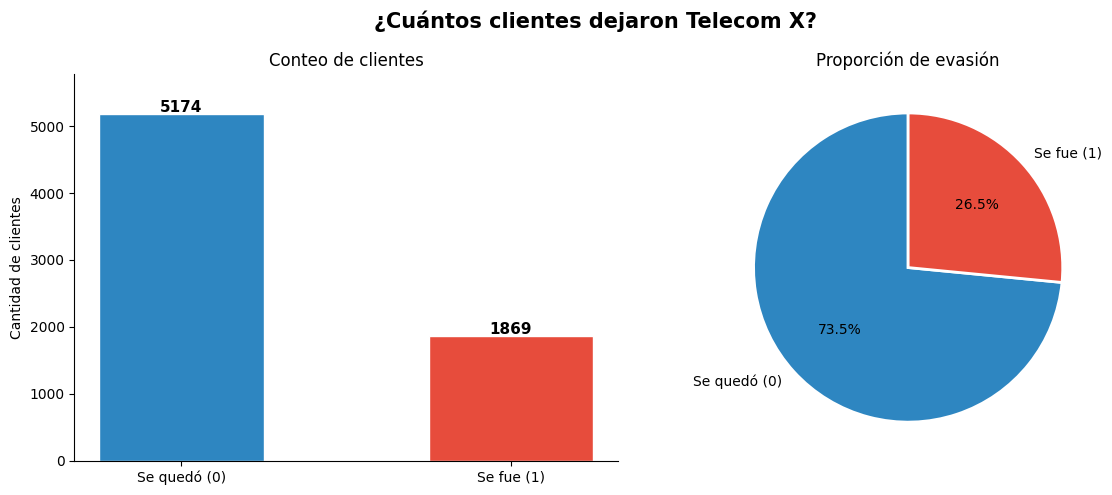

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Colores y etiquetas
colores = ['#2e86c1', '#e74c3c']
etiquetas = ['Se quedó (0)', 'Se fue (1)']

# Crear figura con dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('¿Cuántos clientes dejaron Telecom X?',
             fontsize=15, fontweight='bold')

# Gráfico de barras

axes[0].bar(
    etiquetas,
    conteo.values,
    color=colores,
    edgecolor='white',
    width=0.5
)

# Mostrar solo el número encima de cada barra
for i, v in enumerate(conteo.values):
    axes[0].text(
        i,
        v + 30,
        f'{v}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

axes[0].set_title('Conteo de clientes')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].set_ylim(0, conteo.max() + 600)

sns.despine(ax=axes[0])

# Gráfico de torta

axes[1].pie(
    conteo.values,
    labels=etiquetas,
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

axes[1].set_title('Proporción de evasión')

# Ajustar diseño
plt.tight_layout()
plt.show()

In [24]:
# 📝 1 de cada 4 clientes se fue. Si la empresa no actúa, seguirá perdiendo ingresos mes a mes.
# ⚠️ Los que se quedan son más que los que se van: hay que tener esto en cuenta al construir modelos.

## Cap 3-3 Evasión por Variables Categóricas

In [25]:
# Columnas categóricas y sus etiquetas
cat_cols = {
    'genero':                 'Género',
    'tipo_internet':          'Tipo de Internet',
    'tipo_contrato':          'Tipo de Contrato',
    'metodo_pago':            'Método de Pago',
    'multiples_lineas':       'Líneas Múltiples',
    'seguridad_online':       'Seguridad Online',
    'backup_online':          'Respaldo Online',
    'proteccion_dispositivo': 'Protección de Dispositivo',
    'soporte_tecnico':        'Soporte Técnico',
    'streaming_tv':           'Streaming TV',
    'streaming_peliculas':    'Streaming Películas'
}

In [26]:
promedio_churn = df['Churn'].mean() * 100

In [27]:
# Género
px.histogram(df, x='genero', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Género',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'genero': 'Género', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [28]:
# 📝 Ser hombre o mujer no marca diferencia: ambos cancelan por igual.
# El género no nos ayuda a identificar quién está en riesgo de irse.

In [29]:
# Clientes mayores de 60
px.histogram(df, x='tiene +60', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Clientes Mayores de 60',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'tiene +60': 'Mayor de 60 (1=Sí, 0=No)', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [30]:
# 📝 Los clientes mayores de 60 años se van más que el resto.
# Aunque son pocos, es un grupo que puede sentir que el servicio no está pensado para ellos.
# 🎯 Atenderlos mejor o adaptar la oferta podría reducir sus cancelaciones.

In [31]:
# Posee Pareja
px.histogram(df, x='posee_pareja', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Tenencia de Pareja',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'posee_pareja': 'Posee Pareja (1=Sí, 0=No)', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [32]:
# 📝 Los clientes sin pareja cancelan más.
# Quien comparte el servicio con alguien tiene más motivos para quedarse;
# quien vive solo lo evalúa más fríamente y se va con más facilidad.

In [33]:
# Posee Dependientes
px.histogram(df, x='posee_dependientes', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Tenencia de Dependientes',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'posee_dependientes': 'Posee Dependientes (1=Sí, 0=No)', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [34]:
# 📝 Los clientes sin hijos ni personas a cargo cancelan más.
# Quien tiene familia en casa usa el servicio a diario y no lo cancela tan fácilmente.

In [35]:
# Servicio Telefónico
px.histogram(df, x='servicio_telefono', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Servicio Telefónico',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'servicio_telefono': 'Servicio Telefónico (1=Sí, 0=No)', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [36]:
# 📝 Casi todos los clientes tienen servicio telefónico, así que hay muy poca diferencia entre grupos.
# Este dato no nos ayuda a distinguir quién se va a ir y quién no.

In [37]:
# Tipo de Internet
px.histogram(df, x='tipo_internet', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Tipo de Internet',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'tipo_internet': 'Tipo de Internet', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [38]:
# 📝 El servicio de Fibra óptica es el más popular, pero también el que más cancelaciones tiene.
# Los clientes pagan más y esperan más; cuando la experiencia no lo vale, se van.
# 🎯 Mejorar la calidad percibida de la fibra óptica es urgente.

In [39]:
# Tipo de Contrato
px.histogram(df, x='tipo_contrato', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Tipo de Contrato',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'tipo_contrato': 'Tipo de Contrato', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [40]:
# 📝 Los clientes con contrato mensual se van mucho más que los que tienen contrato anual o de dos años.
# Cuanto mayor es el compromiso, más se queda el cliente.
# 🎯 Ofrecer descuentos o beneficios por contratos más largos puede frenar las cancelaciones.

In [41]:
# Factura Digital
px.histogram(df, x='factura_digital', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Factura Digital',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'factura_digital': 'Factura Digital (1=Sí, 0=No)', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [42]:
# 📝 Los clientes con factura digital cancelan más.
# Recibir la factura por correo hace más fácil ver el cobro, comparar con otras empresas y cancelar.
# 🎯 Vale la pena acompañar este grupo con algún incentivo para mantenerlos.

In [43]:
# Método de Pago
px.histogram(df, x='metodo_pago', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Método de Pago',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'metodo_pago': 'Método de Pago', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [44]:
# 📝 Los clientes que pagan con cheque electrónico cancelan mucho más que los que usan pago automático.
# Cuando el pago es manual, el cliente lo piensa dos veces cada mes; cuando es automático, no.
# 🎯 Incentivar el pago automático es una forma sencilla y económica de reducir cancelaciones.

In [45]:
# Líneas Múltiples
px.histogram(df, x='multiples_lineas', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Líneas Múltiples',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'multiples_lineas': 'Líneas Múltiples', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [46]:
# 📝 Tener una o varias líneas telefónicas no cambia nada: la tasa de cancelación es similar en todos los grupos.
# Esta variable no nos dice mucho sobre quién se va a ir.

In [47]:
# Seguridad Online
px.histogram(df, x='seguridad_online', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Seguridad Online',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'seguridad_online': 'Seguridad Online', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [48]:
# 📝 Los clientes sin seguridad online cancelan bastante más.
# Tener más servicios contratados hace que el cliente sienta que pierde más si se va, y eso lo retiene.

In [49]:
# Respaldo Online
px.histogram(df, x='backup_online', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Respaldo Online',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'backup_online': 'Respaldo Online', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [50]:
# 📝 Sin respaldo online, la cancelación también sube (igual que con seguridad online).
# El patrón es claro: más servicios = menos cancelaciones.
# 🎯 Incluir este servicio en los paquetes básicos puede ayudar a retener clientes nuevos.

In [51]:
# Protección de Dispositivo
px.histogram(df, x='proteccion_dispositivo', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Protección de Dispositivo',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'proteccion_dispositivo': 'Protección de Dispositivo', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [52]:
# 📝 Los clientes sin protección de dispositivo presentan mayor tasa de cancelación.
# Ofrecer este servicio como parte de un paquete podría ser
# una estrategia efectiva para aumentar la retención.

In [53]:
# Soporte Técnico
px.histogram(df, x='soporte_tecnico', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Soporte Técnico',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'soporte_tecnico': 'Soporte Técnico', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [54]:
# 📝 Los clientes sin soporte técnico cancelan más.
# Saber que alguien te ayuda cuando algo falla genera confianza, y eso hace que el cliente se quede.

In [55]:
# Streaming TV
px.histogram(df, x='streaming_tv', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Streaming TV',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'streaming_tv': 'Streaming TV', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [56]:
# 📝 Tener o no streaming de TV no cambia la decisión de cancelar.
# Es un servicio que los clientes valoran, pero no es razón suficiente para quedarse.

In [57]:
# Streaming Películas
px.histogram(df, x='streaming_peliculas', color='Churn', barmode='group',
             text_auto=True, title='Evasión por Streaming Películas',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'streaming_peliculas': 'Streaming Películas', 'count': 'Cantidad de clientes', 'Churn': 'Estado'})

In [58]:
# 📝 Igual que con el streaming TV: tenerlo o no tenerlo no influye en la cancelación.
# El entretenimiento no es lo que hace que un cliente decida quedarse en Telecom X.

## Cap 3-4 Evasión por Variables Numéricas

In [59]:
# Tiempo de Contrato
px.histogram(df, x='tiempo_contrato', color='Churn', barmode='overlay',
             text_auto=True, title='Distribución de Tiempo de Contrato según Evasión',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'tiempo_contrato': 'Tiempo de contrato (meses)', 'count': 'Cantidad de clientes', 'Churn': 'Estado'},
             opacity=0.7)

In [60]:
# 📝 La mayoría de los clientes que se van lo hacen en los primeros meses.
# Después del primer año, muy pocos cancelan: el cliente ya se acostumbró al servicio.
# 🎯 El primer año es la ventana crítica: ahí hay que cuidar más al cliente.

In [61]:
# Cargo Mensual
px.histogram(df, x='valor_mensal', color='Churn', barmode='overlay',
             text_auto=True, title='Distribución de Cargo Mensual según Evasión',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'valor_mensal': 'Cargo mensual ($)', 'count': 'Cantidad de clientes', 'Churn': 'Estado'},
             opacity=0.7)

In [62]:
# 📝 Los clientes que pagan más al mes se van más.
# Generalmente son clientes nuevos con el plan más caro (fibra óptica mensual):
# si sienten que no lo vale, cancelan sin dudar.

In [63]:
# Total Cobrado
px.histogram(df, x='total_cobrado', color='Churn', barmode='overlay',
             text_auto=True, title='Distribución de Total Cobrado según Evasión',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'total_cobrado': 'Total cobrado ($)', 'count': 'Cantidad de clientes', 'Churn': 'Estado'},
             opacity=0.7)

In [64]:
# 📝 Los clientes que cancelan llevan poco tiempo y han pagado poco en total.
# Cuanto más tiempo lleva un cliente pagando, menos probable es que se vaya:
# ya se quedó, ya confía, ya es parte de la base fiel.

In [65]:
# Cargo Diario
px.histogram(df, x='cuentas_diarias', color='Churn', barmode='overlay',
             text_auto=True, title='Distribución de Cargo Diario según Evasión',
             color_discrete_map={0: '#2e86c1', 1: '#e74c3c'},
             labels={'cuentas_diarias': 'Cargo diario ($)', 'count': 'Cantidad de clientes', 'Churn': 'Estado'},
             opacity=0.7)

In [66]:
# 📝 El cargo diario muestra lo mismo que el mensual: quienes pagan más por día cancelan más.
# Desglosar el costo en días hace visible que algunos clientes pagan demasiado por lo que reciben.

# 📄 Informe Final — Telecom X: Análisis de Evasión de Clientes

## 1. Introducción

Telecom X enfrenta un problema concreto: **1 de cada 4 clientes cancela el servicio** *(ver Cap 3-2: Distribución de Evasión)*.

El objetivo de este análisis fue entender *por qué* se van los clientes y *qué características* comparten quienes cancelan, para que la empresa pueda tomar decisiones con base en datos y no en suposiciones.

Para eso se trabajó con la base de datos de clientes de Telecom X, que contiene información sobre el perfil de cada usuario, los servicios que tiene contratados, cómo paga y cuánto tiempo lleva como cliente.

## 2. Limpieza y tratamiento de datos

Los datos llegaron en formato JSON con columnas anidadas (cliente, teléfono, internet, cuenta). Se aplicaron los siguientes pasos:

- **Extracción:** datos cargados directamente desde una URL pública, convertidos a tabla con Pandas.
- **Normalización:** se expandió la estructura anidada para obtener una columna por campo.
- **Limpieza:** se eliminaron filas con el campo de cancelación vacío (sin categoría válida). No se encontraron duplicados.
- **Conversión de tipos:** los campos de cobro mensual y total estaban como texto; se convirtieron a número.
- **Nueva columna:** se calculó el cargo diario (cobro mensual ÷ 30) para tener una visión más detallada del gasto por día.
- **Estandarización:** los valores "Yes/No" se convirtieron a 1/0 y los textos en inglés se tradujeron al español para facilitar la lectura.

## 3. Análisis exploratorio

Se analizaron tres etapas. Los gráficos y tablas que respaldan cada hallazgo se encuentran desarrollados en los capítulos 3-1, 3-2, 3-3 y 3-4.

**Estadísticas descriptivas** *(Cap 3-1)*
Se calculó el resumen numérico del conjunto de datos (promedios, mínimos, máximos, distribución). Esto permitió entender los rangos de cobro, el tiempo promedio de contrato y la distribución general de los clientes antes de profundizar en el análisis.

**Distribución general de cancelaciones** *(Cap 3-2)*
El 26% de los clientes canceló. La mayoría se queda, pero la proporción de los que se van es suficientemente alta como para representar una pérdida de ingresos real y sostenida.

**Variables categóricas** — ¿qué tipo de cliente cancela más? *(Cap 3-3)*

| Variable | Hallazgo |
|---|---|
| Género | Sin diferencia. Hombres y mujeres cancelan igual. |
| Mayor de 60 años | Los clientes mayores de 60 se van más que el resto. |
| Con pareja | Los clientes sin pareja cancelan más que los que sí tienen. |
| Con dependientes | Los clientes sin hijos ni personas a cargo cancelan más. |
| Tipo de internet | Fibra óptica tiene la mayor cantidad de cancelaciones. |
| Tipo de contrato | El contrato mensual concentra casi toda la evasión. |
| Factura digital | Los clientes con factura digital cancelan más. |
| Método de pago | El cheque electrónico está muy asociado a cancelaciones. |
| Servicio telefónico | Sin diferencia útil: casi todos lo tienen. |
| Líneas múltiples | Sin diferencia relevante entre grupos. |
| Seguridad online | Sin este servicio, cancelan más. |
| Respaldo online | Sin este servicio, cancelan más. |
| Protección de dispositivo | Sin este servicio, cancelan más. |
| Soporte técnico | Sin este servicio, cancelan más. |
| Streaming TV / Películas | Sin diferencia. No influye en la decisión de quedarse. |

**Variables numéricas** — ¿qué números marcan la diferencia? *(Cap 3-4)*

| Variable | Hallazgo |
|---|---|
| Tiempo de contrato | Los que se van llevan pocos meses. Pasado el primer año, casi nadie cancela. |
| Cobro mensual | A mayor cobro mensual, más cancelaciones. |
| Total cobrado | Los que cancelan han pagado poco en total: son clientes nuevos. |
| Cobro diario | Confirma el mismo patrón que el cobro mensual. |

## 4. Conclusiones e insights

El análisis muestra que los clientes que cancelan comparten un perfil bastante claro *(Cap 3-3 y Cap 3-4)*:

- Llevan **pocos meses** como clientes — la mayoría se va antes de cumplir el primer año *(ver Cap 3-4: Tiempo de Contrato)*.
- Tienen **contrato mensual** — el de menor compromiso *(ver Cap 3-3: Tipo de Contrato)*.
- Usan **fibra óptica** y pagan un cobro mensual alto *(ver Cap 3-3: Tipo de Internet y Cap 3-4: Cobro Mensual)*.
- Pagan con **cheque electrónico** — el único método que no es automático *(ver Cap 3-3: Método de Pago)*.
- Tienen **factura digital** — acceso fácil al detalle del cobro y a comparar con otras empresas *(ver Cap 3-3: Factura Digital)*.
- **No tienen servicios adicionales** como seguridad online, respaldo ni soporte técnico *(ver Cap 3-3: Seguridad, Respaldo, Soporte)*.
- Son clientes **mayores de 60 años**, **sin pareja** o **sin personas a cargo** — perfiles con menos razones cotidianas para mantener el servicio activo *(ver Cap 3-3: Mayor de 60, Con pareja, Con dependientes)*.

En resumen: el cliente que cancela es nuevo, paga caro, vive solo o no tiene familia que dependa del servicio, y revisa su factura cada mes.

El cliente fiel, en cambio, tiene contrato largo, pago automático, varios servicios contratados y una familia que usa el servicio a diario.

## 5. Recomendaciones

**1. Blindar el primer año** *(ver Cap 3-4: Tiempo de Contrato)*
La mayoría de cancelaciones ocurre en los primeros meses. Un programa de bienvenida con seguimiento durante los primeros 12 meses puede marcar la diferencia.

**2. Incentivar contratos más largos** *(ver Cap 3-3: Tipo de Contrato)*
Ofrecer descuentos o beneficios a quienes pasen del plan mensual al anual o bienal. Un cliente con contrato largo casi nunca cancela.

**3. Promover el pago automático** *(ver Cap 3-3: Método de Pago)*
Los clientes con pago automático cancelan mucho menos. Un pequeño descuento por activarlo puede generar gran impacto en retención.

**4. Revisar la experiencia con fibra óptica** *(ver Cap 3-3: Tipo de Internet)*
Es el servicio más contratado y el que más cancelaciones genera. Hay que entender si el problema es el precio, la calidad o las expectativas del cliente.

**5. Incluir servicios adicionales en los paquetes básicos** *(ver Cap 3-3: Seguridad Online, Respaldo Online, Soporte Técnico)*
Los clientes que tienen más servicios se quedan más. Incluirlos desde el inicio, aunque sea en versión básica, aumenta las razones para quedarse.

**6. Atención especial a clientes mayores de 60 años** *(ver Cap 3-3: Mayor de 60)*
Este grupo cancela más. Vale la pena ofrecerles atención personalizada o un plan adaptado a sus necesidades.

**7. Acompañar a clientes solos sin familia** *(ver Cap 3-3: Con pareja, Con dependientes)*
Los clientes sin pareja ni dependientes no tienen a nadie más usando el servicio en casa, por lo que les cuesta menos cancelar. Fidelizarlos requiere mostrarles valor de forma más directa.